In [47]:
""" Find all the read out err
1. raed time_unzip_take.csv 
2. read time_pwv_take*.csv to see read errors(when time is zero) & print total time take(Total time taken)

"""

import pandas as pd
import glob 

#Create txt to record errors
with open('readOutErr.txt', 'w') as f:
    f.write("Read Out Errors:\n\n")

#Archive Errors
#open the time_unzip_take.csv
data = pd.read_csv('saveCSV/time_unzip_take.csv', dtype={"TIME": str,"take TIME (seconds)": float})
for i in range(len(data)):
    if data['TIME'][i].startswith('unzip'):
        if data['take TIME (seconds)'][i] < 0.03:
            with open('readOutErr.txt', 'a+') as f:
                #print(f"{data['TIME'][i]} ")
                f.write(f"{data['TIME'][i]}\t{data['take TIME (seconds)'][i]}\n")
            f.close()
print("Archive Errors saved to readOutErr.txt")

#find all time_pwv_take*.csv files
files = glob.glob('saveCSV/time_pwv_take*.csv')
  
#save all output to a file
with open('readOutErr.txt', 'a+') as f:
    for file in files:
        #print(f"Processing file: {file}")
        
        df = pd.read_csv(file)
        zero_time = df[df['take TIME (seconds)'] == 0]
        if not zero_time.empty:
            f.write(f"\nProcessing file: {file}\n")
            f.write(f"File: {file} has zero time values:\n")
            f.write(zero_time.to_string() + '\n')
    
    f.write("\nTotal time taken for each file:\n\n")
    
    total_num = 0
    for file in files:
        df = pd.read_csv(file)
        f.write(f"For {file}\nTotal time taken: {df['TIME'].tolist()[-1]}\n")
        num = len(df)
        total_num += num/7
        f.write(f"About {num/7:.0f} rows\n\n")
    print(f"Total number of rows processed: {total_num}")
f.close()


print("Output saved to output.txt")

            



Archive Errors saved to readOutErr.txt
Total number of rows processed: 6430.857142857141
Output saved to output.txt


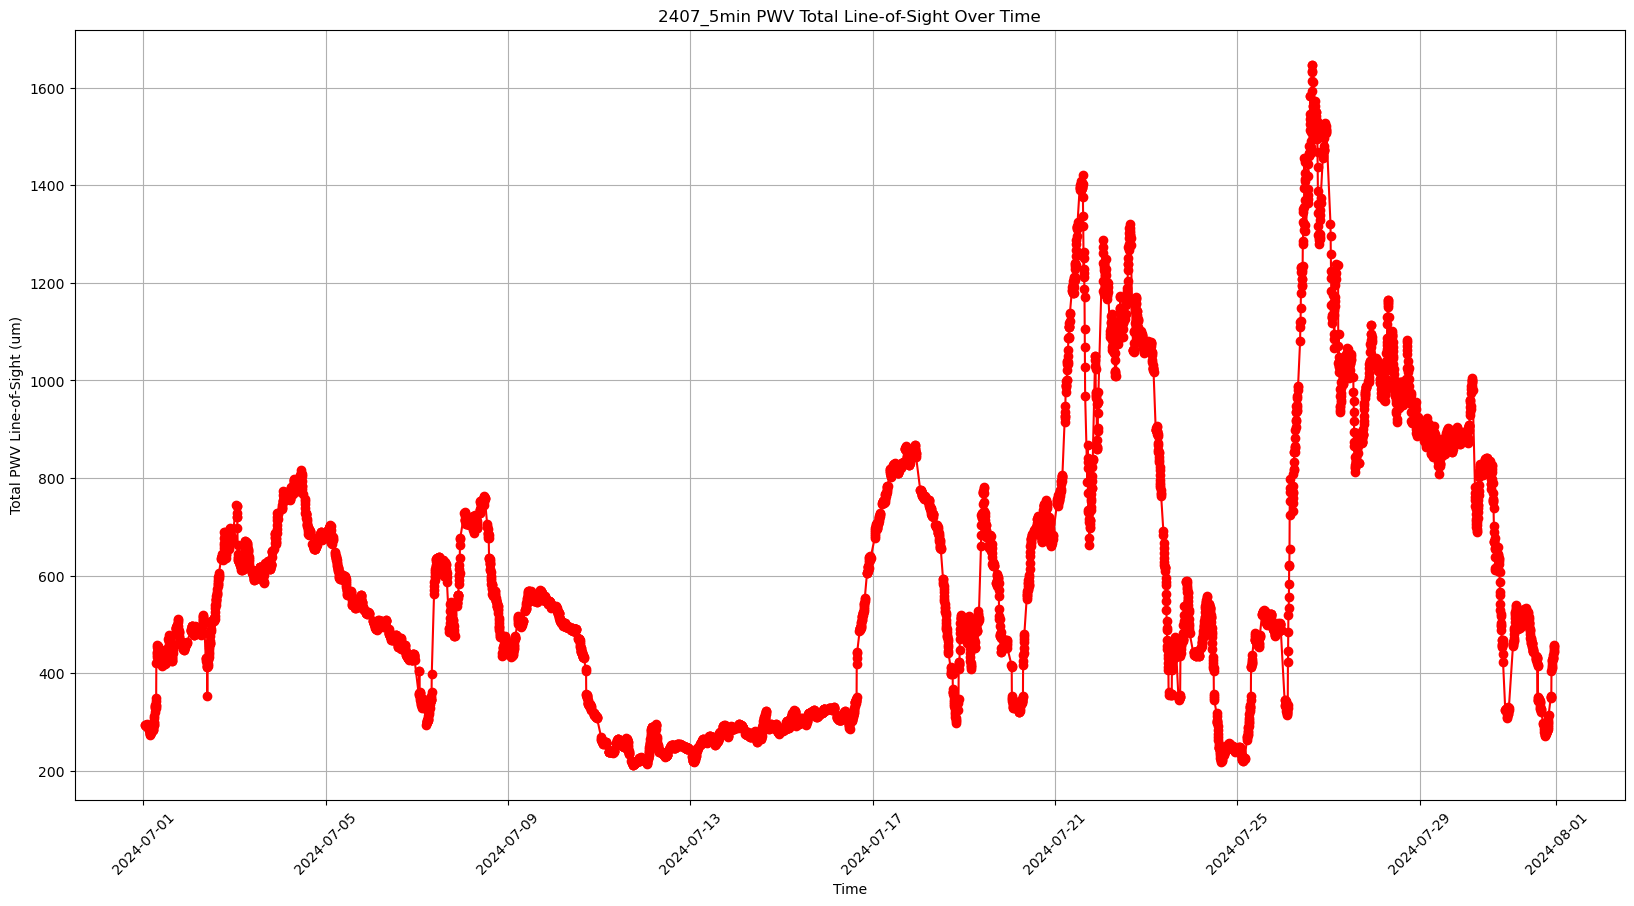

In [3]:
# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 

#Winter Dec Jan Feb
#Spring Mar Apr May
#Summer Jun Jul Aug
#Autumn Sep Oct Nov

#seasons = ['All','Winter24', 'Spring', 'Summer', 'Autumn','Winter25']

#files = glob.glob('saveCSV/time_pwv_2*.csv')

#files = ['saveCSV/time_pwv_2401.csv', 'saveCSV/time_pwv_2402.csv']

#files = ['saveCSV/time_pwv_2403.csv', 'saveCSV/time_pwv_2404.csv', 'saveCSV/time_pwv_2405.csv']

#files = ['saveCSV/time_pwv_2406.csv', 'saveCSV/time_pwv_2407.csv', 'saveCSV/time_pwv_2408.csv']

#files = ['saveCSV/time_pwv_2409.csv', 'saveCSV/time_pwv_2410.csv', 'saveCSV/time_pwv_2411.csv']
#files = ['saveCSV/time_pwv_2412.csv', 'saveCSV/time_pwv_2501.csv']

files = ['saveCSV/time_pwv_2407.csv']

season = "2407_5min"
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []

for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

# plot the data
plt.figure(figsize=(20, 10))
plt.plot(TIME, PWV_TOTAL_zenith, marker='o', linestyle='-', color='b')
plt.title(f'{season} PWV Total Zenith Over Time')
plt.xlabel('Time')
plt.ylabel('Total PWV Zenith (um)')
plt.xticks(rotation=45)
plt.grid()

plt.savefig(f'saveCSV/plots/{season}_pwv_total_zenith_over_time.png', dpi=300)
plt.savefig(f'saveCSV/plots/{season}_pwv_total_zenith_over_time.svg')

plt.close()

plt.figure(figsize=(20, 10))
plt.plot(TIME, PWV_TOTAL_line_of_sight, marker='o', linestyle='-', color='r')
plt.title(f'{season} PWV Total Line-of-Sight Over Time')
plt.xlabel('Time')
plt.ylabel('Total PWV Line-of-Sight (um)')
plt.xticks(rotation=45)
plt.grid()

plt.savefig(f'saveCSV/plots/{season}_pwv_total_line_of_sight_over_time.png', dpi=300)
plt.savefig(f'saveCSV/plots/{season}_pwv_total_line_of_sight_over_time.svg')
plt.show()
plt.close()

plt.figure(figsize=(20, 10))
plt.hist(PWV_TOTAL_zenith, bins=50, color='blue', alpha=0.7)
plt.title(f'{season} Histogram of PWV Total Zenith')
plt.xlabel('Total PWV Zenith (um)') 
plt.ylabel('Number of Occurrences')
plt.grid()
plt.savefig(f'saveCSV/plots/{season}_histogram_pwv_total_zenith.png', dpi=300)
plt.savefig(f'saveCSV/plots/{season}_histogram_pwv_total_zenith.svg')
#plt.show()
plt.close()


Fitted exponential: y = 27.769 * e^(-0.375x)


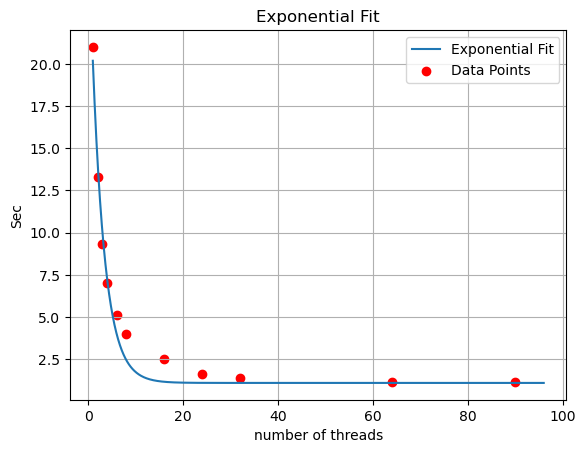

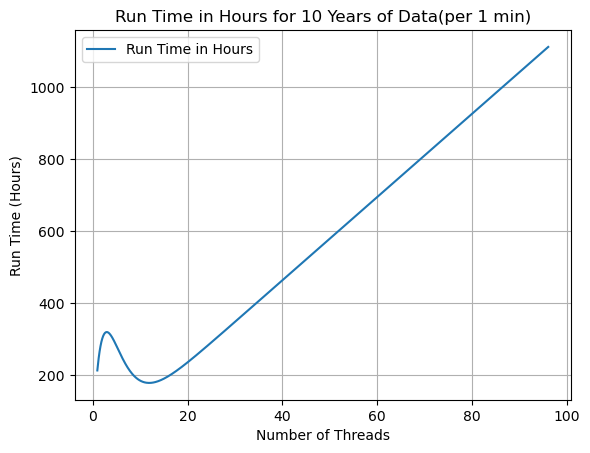

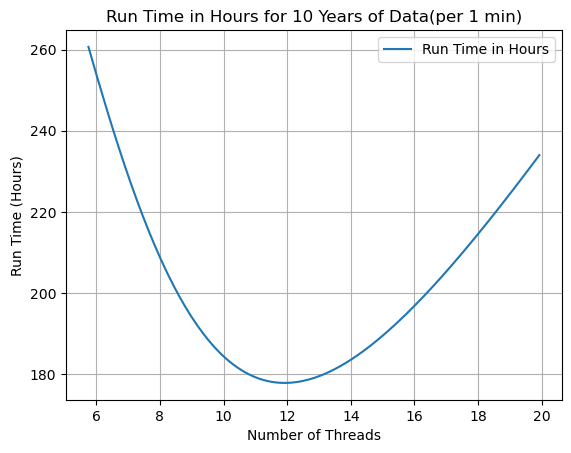

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the exponential function
def exp_func(x, a, b):
    return a * np.exp(b * x) + 1.1

# Given data points
x_data = np.array([1,   2,  3,      4,   6, 8, 16,  24,   32, 64,   90])
t_data = np.array([21, 13.3, 9.3, 7.3, 5.1, 4, 2.5, 1.6, 1.4, 1.15, 1.15])


h_data = (t_data * 500 * 6) / 3600  # Convert to hours
#print("Hours data: ", h_data)

# Fit the exponential model
params, _ = curve_fit(exp_func, x_data, t_data, p0=(0.1, -0.1))  # p0 is initial guess
a, b = params
print(f"Fitted exponential: y = {a:.3f} * e^({b:.3f}x)")

# Generate smooth curve for plotting
x = np.linspace(1, 96, 1000)
t = exp_func(x, a, b)
#print("Fitted time data: ", t)
# h = (t * 500*6)/3600 

# Plot
plt.plot(x, t, label='Exponential Fit')
plt.scatter(x_data, t_data, color='red', label='Data Points')
plt.title("Exponential Fit")
plt.xlabel("number of threads")
plt.ylabel("Sec")
plt.grid(True)
plt.legend()
plt.show()
plt.close()

#For time take in hours to data 10 years'data 1 mins each
num_dat = 500*60 #one month 
num_sys_run = 120 / (95/x) #num of month run together
#print(f"Number of months run together: {num_sys_run}")
run_time = (num_dat * num_sys_run * t) / 3600  # Convert to hours

plt.plot(x[0:], run_time[0:], label='Run Time in Hours')
plt.title("Run Time in Hours for 10 Years of Data(per 1 min)")
plt.xlabel("Number of Threads")
plt.ylabel("Run Time (Hours)")
plt.grid(True)
plt.legend()
plt.show()

plt.plot(x[50:200], run_time[50:200], label='Run Time in Hours')
plt.title("Run Time in Hours for 10 Years of Data(per 1 min)")
plt.xlabel("Number of Threads")
plt.ylabel("Run Time (Hours)")
plt.grid(True)
plt.legend()
plt.show()


